In [1]:
import torch 
from matplotlib import pyplot as plt
import numpy as np
from GaNN.models.GaNN import GaNN
from GaNN.synth import generate
from GaNN.synth import utils 
from GaNN.train.train import train

%load_ext autoreload
%autoreload 2

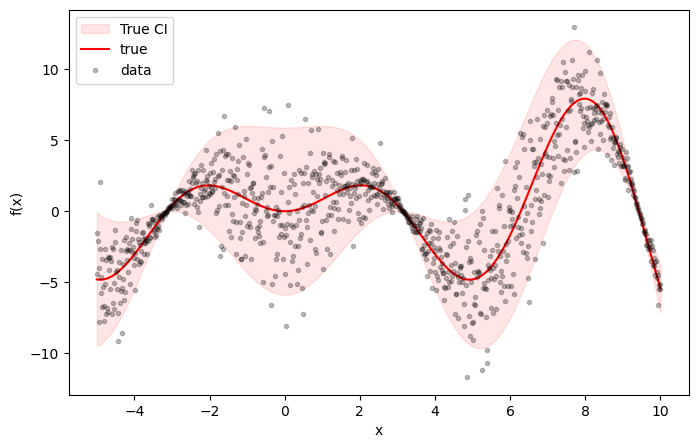

In [2]:
x,y,y_true,true_lcb,true_ucb = generate.simple1d(N=1000, scale=3)

utils.plot1d(x,y,y_true,true_lcb,true_ucb)

In [3]:
num_epochs = 1000
samples = 1000 
batch_size = 100
lr = 1e-4
hidden_channels = 25
layers = 2
gaussian_channels = 50
width = 250
compile = False

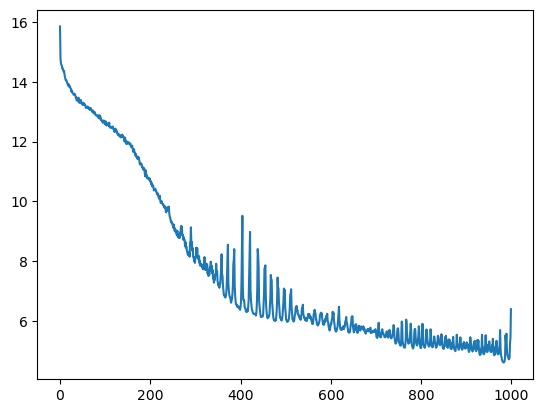

In [4]:
model, losses = train(x.view(-1,1),y.view(-1,1), loss_fn='mse', model_kwargs={'hidden_channels':hidden_channels, 
                                                               'layers':layers, 
                                                               'gaussian_channels':gaussian_channels, 
                                                               'width':width},
                        lr=lr, batch_size=batch_size, num_epochs=num_epochs, compile=compile)

plt.figure()
plt.plot(losses)
plt.show()

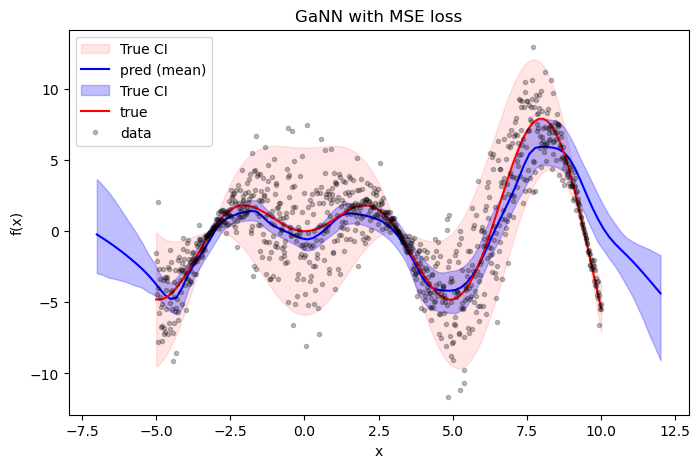

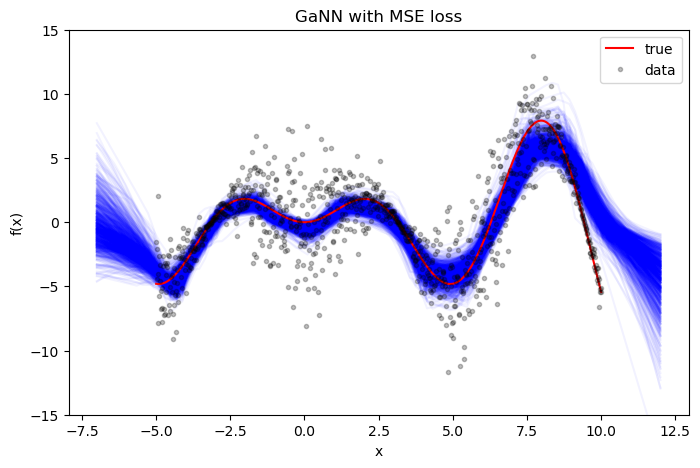

In [5]:
x2 = torch.linspace(-7,12,100)
yhat = model(x2.unsqueeze(1), 1000)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='GaNN with MSE loss')
utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='GaNN with MSE loss', plot_ci=False, ylim=(-15,15))

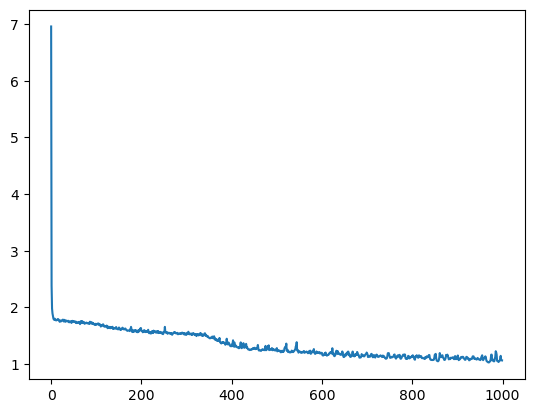

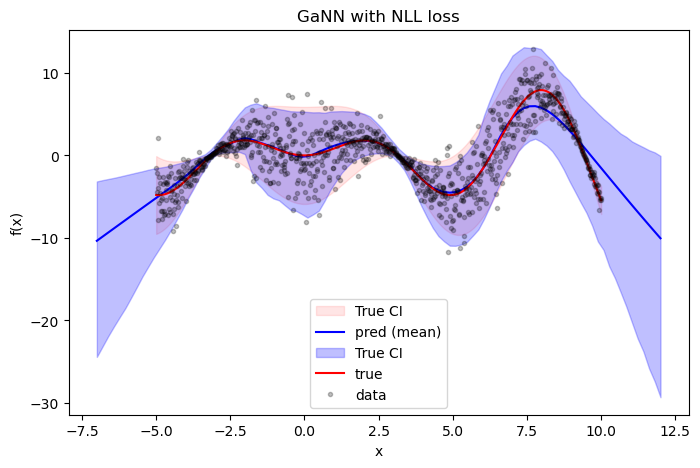

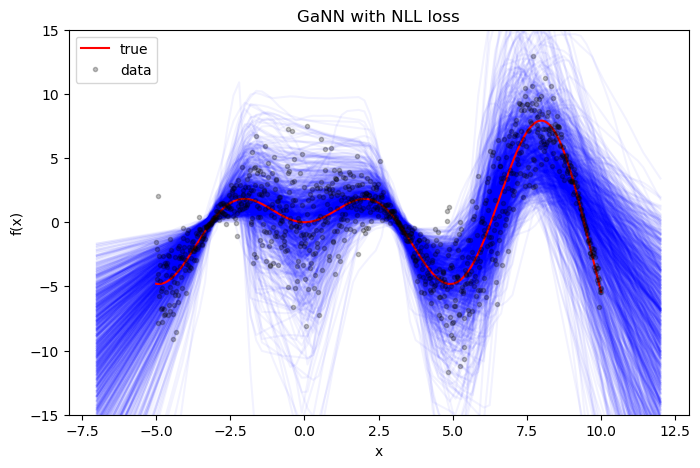

In [6]:
model, losses = train(x.view(-1,1),y.view(-1,1), loss_fn='nll', model_kwargs={'hidden_channels':hidden_channels, 
                                                               'layers':layers, 
                                                               'gaussian_channels':gaussian_channels, 
                                                               'width':width},
                        lr=lr, batch_size=batch_size, num_epochs=num_epochs, compile=compile)

plt.figure()
plt.plot(losses)
plt.show()

x2 = torch.linspace(-7,12,100)
yhat = model(x2.unsqueeze(1), 1000)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='GaNN with NLL loss')
utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='GaNN with NLL loss', plot_ci=False, ylim=(-15,15))

In [7]:
model, losses = train(x.view(-1,1),y.view(-1,1), loss_fn='nll', model_kwargs={'hidden_channels':hidden_channels, 
                                                               'layers':layers, 
                                                               'gaussian_channels':gaussian_channels, 
                                                               'width':width, 
                                                               'nonlin':'relu'},
                        lr=lr, batch_size=batch_size, num_epochs=num_epochs, compile=compile)

plt.figure()
plt.plot(losses)
plt.show()

x2 = torch.linspace(-7,12,100)
yhat = model(x2.unsqueeze(1), 1000)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='ReLU')
utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='ReLU', plot_ci=False, ylim=(-15,15))

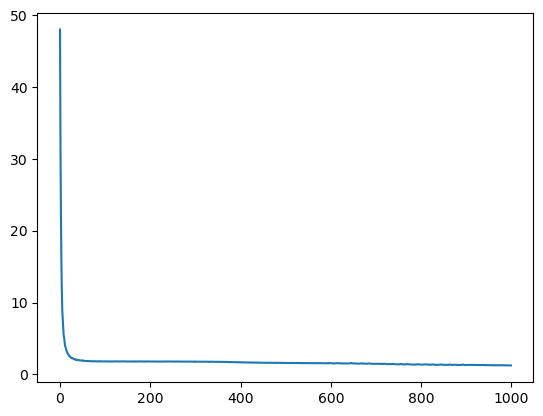

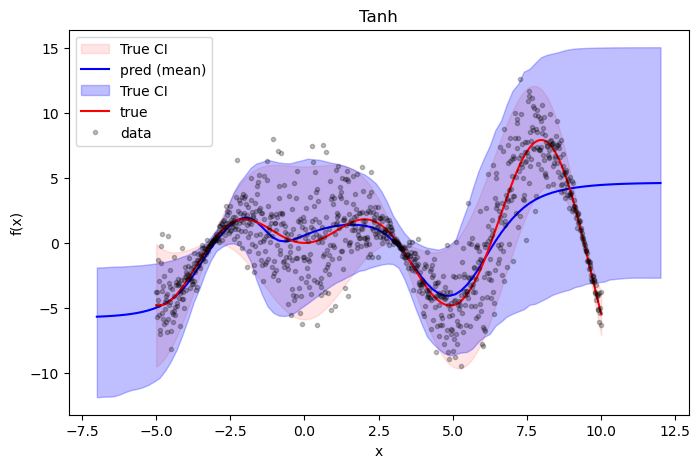

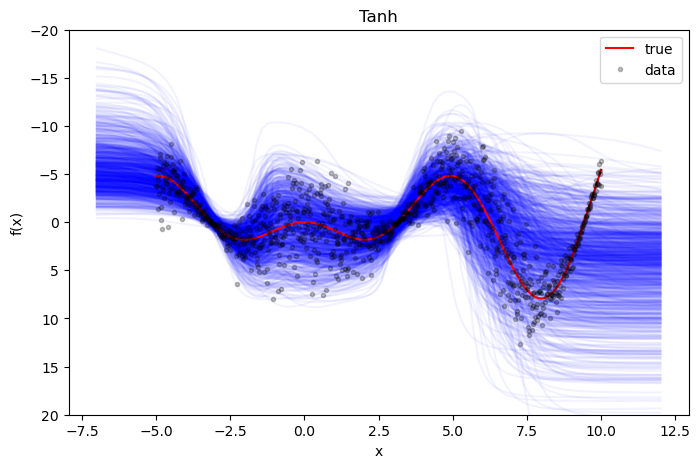

In [31]:
model, losses = train(x.view(-1,1),y.view(-1,1), loss_fn='nll', model_kwargs={'hidden_channels':hidden_channels, 
                                                               'layers':layers, 
                                                               'gaussian_channels':gaussian_channels, 
                                                               'width':width, 
                                                               'nonlin':'tanh'},
                        lr=lr, batch_size=batch_size, num_epochs=num_epochs, compile=compile)

plt.figure()
plt.plot(losses)
plt.show()

x2 = torch.linspace(-7,12,100)
yhat = model(x2.unsqueeze(1), 1000)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='Tanh')
utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='Tanh', plot_ci=False, ylim=(-15,15))

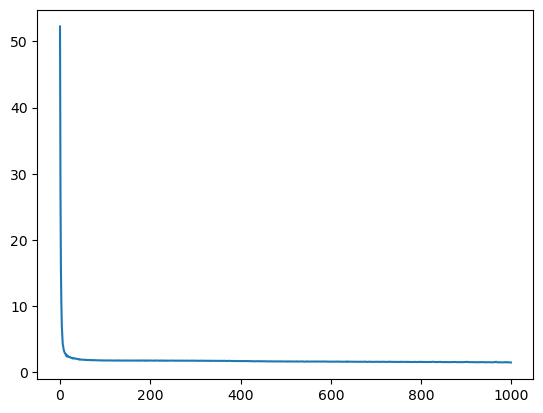

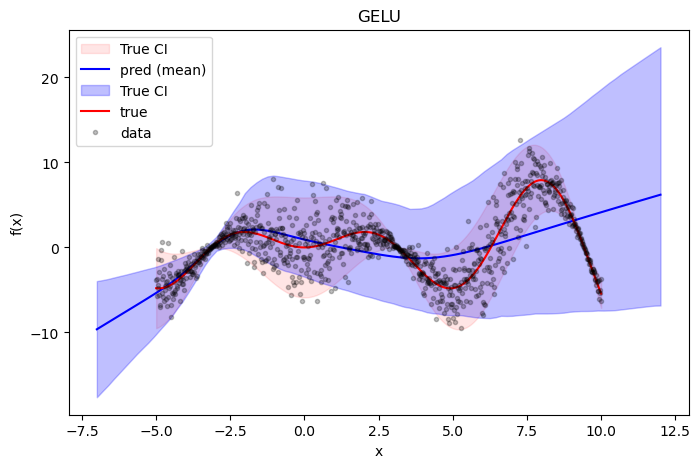

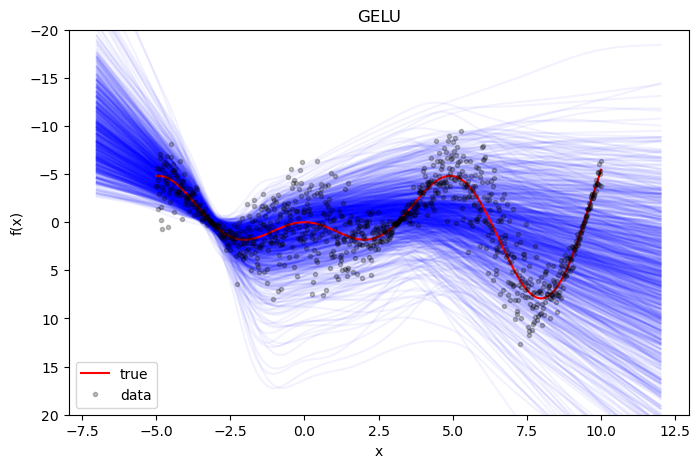

In [32]:
model, losses = train(x.view(-1,1),y.view(-1,1), loss_fn='nll', model_kwargs={'hidden_channels':hidden_channels, 
                                                               'layers':layers, 
                                                               'gaussian_channels':gaussian_channels, 
                                                               'width':width, 
                                                               'nonlin':'gelu'},
                        lr=lr, batch_size=batch_size, num_epochs=num_epochs, compile=compile)

plt.figure()
plt.plot(losses)
plt.show()

x2 = torch.linspace(-7,12,100)
yhat = model(x2.unsqueeze(1), 1000)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='GELU')
utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='GELU', plot_ci=False, ylim=(-15,15))

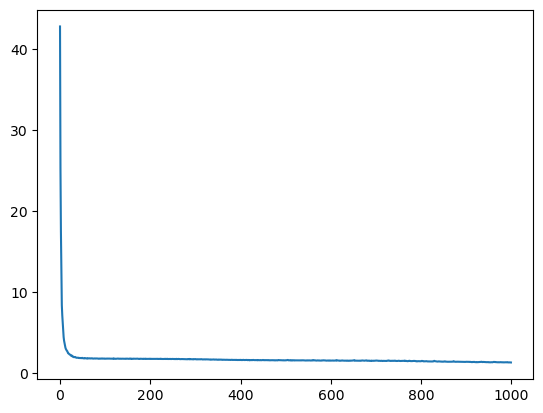

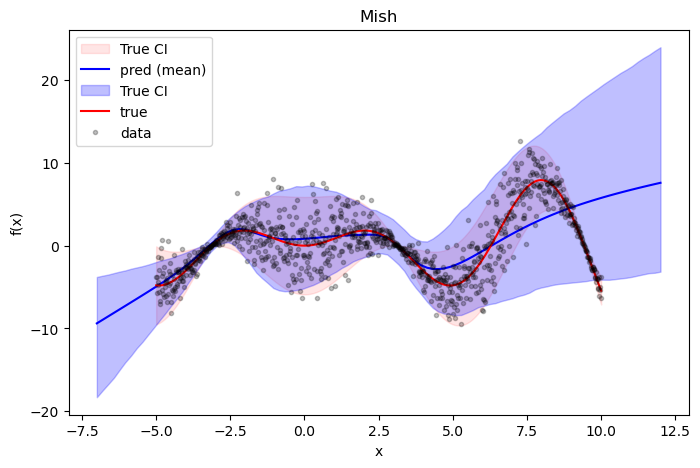

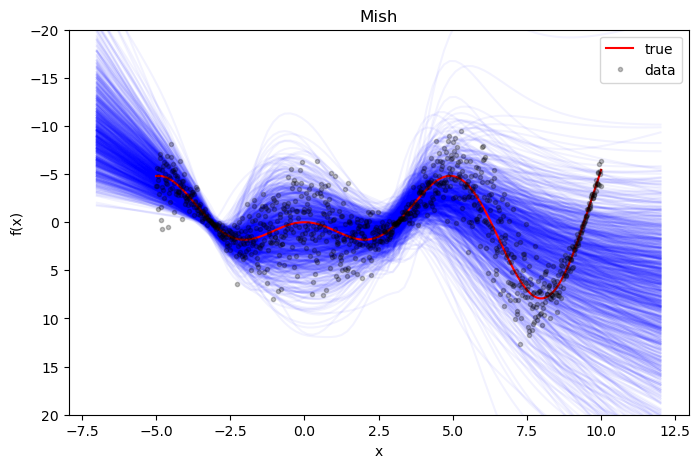

In [33]:
model, losses = train(x.view(-1,1),y.view(-1,1), loss_fn='nll', model_kwargs={'hidden_channels':hidden_channels, 
                                                               'layers':layers, 
                                                               'gaussian_channels':gaussian_channels, 
                                                               'width':width, 
                                                               'nonlin':'mish'},
                        lr=lr, batch_size=batch_size, num_epochs=num_epochs, compile=compile)

plt.figure()
plt.plot(losses)
plt.show()

x2 = torch.linspace(-7,12,100)
yhat = model(x2.unsqueeze(1), 1000)

utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='Mish')
utils.plot1d(x,y,y_true,true_lcb,true_ucb, x2, yhat, title='Mish', plot_ci=False, ylim=(-15,15))

In [34]:
# create a symmetric dataset, our method should effectively identify both local minimia 

# use val to select optimal performing z values. 

# quantify epistemic vs aleatoric - 
#   aleatoric = GaNN_MSE - GaNN_NLL
#   epistemic = GaNN_NLL ... ? 